# 쇼핑몰 판매량 예측 (Sales Forecasting)

## 1. 데이터 설명
이 데이터셋은 특정 기준일부터 과거의 일별 판매량(Sales) 데이터와 제품의 메타 데이터(제품 정보, 특성, 브랜드 키워드 카운트 등)를 바탕으로 향후 21일간의 제품별 판매량을 예측하기 위해 수집되었습니다.

- `train.csv`: 각 제품(ID)에 대해 대분류, 중분류, 소분류, 브랜드 정보와 함께 2022-01-01부터 2023-04-04까지의 일별 판매량 데이터가 포함되어 있습니다.
- `sales.csv`: 제품별 총 판매/매출 정보(train.csv와 유사한 형태)를 담고 있습니다.
- `product_info.csv`: 제품 단위의 세부 특성(제품특성) 정보가 포함되어 있습니다.
- `brand_keyword_cnt.csv`: 각 브랜드별로 동일 기간(2022-01-01 ~ 2023-04-04) 동안의 포털 검색(키워드) 카운트 데이터가 포함되어 브랜드의 트렌드 지표로 활용할 수 있습니다.
- `sample_submission.csv`: 예측해야 할 타겟 기간인 2023-04-05부터 2023-04-25까지의 날짜 범위가 컬럼으로 주어져 있으며, 예측값을 기입하여 제출하는 양식입니다.

## 2. 문제 정의
**목표**: 과거 459일(2022-01-01 ~ 2023-04-04) 동안의 일별 판매량, 브랜드 인지도(검색량) 및 제품의 계층적 카테고리(대/중/소분류) 정보를 활용하여, **향후 21일(2023-04-05 ~ 2023-04-25) 동안의 각 제품별 일일 판매량을 예측하는 회귀(Regression) 또는 시계열 모델링(Time Series Forecasting) 문제**입니다.

- **다변량 시계열(Multivariate Time Series) 예측**: 브랜드 검색량 트렌드와 같은 외부 특성을 반영하여 판매량 트렌드를 예측해야 합니다.
- **콜드 스타트 혹은 희소 데이터**: 제품별 판매량이 간헐적으로 0인 구간이 많아 데이터의 희소성(Sparsity)이 크므로 이를 어떻게 처리할지가 중요합니다.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

import warnings
warnings.filterwarnings('ignore')

In [1]:
# 한글 폰트 셀
import matplotlib.pyplot as plt
import seaborn as sns
from korean_font import set_korean_font

set_korean_font()
plt.rcParams['font.size'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['axes.labelsize'] = 10

한글 폰트 설정: NanumGothic (/usr/share/fonts/truetype/nanum/NanumGothic.ttf)


## 3. 데이터셋 탐색 (Data Exploration)

In [2]:
base_path = './data/'
train_path = os.path.join(base_path, 'train.csv')
sales_path = os.path.join(base_path, 'sales.csv')
brand_path = os.path.join(base_path, 'brand_keyword_cnt.csv')
product_path = os.path.join(base_path, 'product_info.csv')
submission_path = os.path.join(base_path, 'sample_submission.csv')

# 데이터 로드
# train 데이터
train = pd.read_csv(train_path)
# 기타 참조 데이터
brand_cnt = pd.read_csv(brand_path)
product_info = pd.read_csv(product_path)
submission = pd.read_csv(submission_path)

print(f"Train 데이터 형태: {train.shape}")
print(f"Sample Submission 형태: {submission.shape}")

Train 데이터 형태: (15890, 465)
Sample Submission 형태: (15890, 22)


In [3]:
display(train.head())
display(brand_cnt.head())

,ID,제품,대분류,중분류,소분류,브랜드,2022-01-01,2022-01-02,2022-01-03,2022-01-04,...,2023-03-26,2023-03-27,2023-03-28,2023-03-29,2023-03-30,2023-03-31,2023-04-01,2023-04-02,2023-04-03,2023-04-04
0,0,B002-00001-00001,B002-C001-0002,B002-C002-0007,B002-C003-0038,B002-00001,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,B002-00002-00001,B002-C001-0003,B002-C002-0008,B002-C003-0044,B002-00002,0,0,0,0,...,0,0,0,1,3,2,0,0,2,0
2,2,B002-00002-00002,B002-C001-0003,B002-C002-0008,B002-C003-0044,B002-00002,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,3,B002-00002-00003,B002-C001-0003,B002-C002-0008,B002-C003-0044,B002-00002,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,B002-00003-00001,B002-C001-0001,B002-C002-0001,B002-C003-0003,B002-00003,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


,브랜드,2022-01-01,2022-01-02,2022-01-03,2022-01-04,2022-01-05,2022-01-06,2022-01-07,2022-01-08,2022-01-09,...,2023-03-26,2023-03-27,2023-03-28,2023-03-29,2023-03-30,2023-03-31,2023-04-01,2023-04-02,2023-04-03,2023-04-04
0,B002-00001,0.84131,0.91383,1.450530,2.422390,1.871190,1.581080,1.232950,1.174930,1.145920,...,0.319110,0.391640,0.377130,0.49318,0.072520,0.29010,0.31911,0.232080,0.333620,0.44966
1,B002-00002,12.64868,20.27850,15.332170,12.750210,13.562510,13.707570,11.937910,15.564250,14.084710,...,10.269790,11.966920,10.646930,10.41485,10.487380,9.48651,9.28343,10.429350,11.154620,11.38671
2,B002-00003,0.33362,0.43516,0.362630,0.174060,0.217580,0.464170,0.420650,0.290100,0.377130,...,0.536690,0.696250,0.449660,0.39164,1.029880,0.49318,0.91383,0.797790,1.015370,0.88482
3,B002-00005,1.07339,1.71163,2.016240,1.914700,1.987230,2.146790,1.682620,1.378000,1.421520,...,2.219320,2.509420,2.872060,2.37888,2.030750,1.53756,1.34899,1.261960,2.320850,2.30635
4,B002-00006,0.00000,0.00000,0.188558,0.246574,0.246574,0.246574,0.377139,0.087012,0.261084,...,0.072526,0.290103,0.087012,0.00000,0.130542,0.00000,0.00000,0.072526,0.217577,0.00000


## 4. 탐색적 데이터 분석 (EDA)

Date 컬럼 결측치 총합: 0


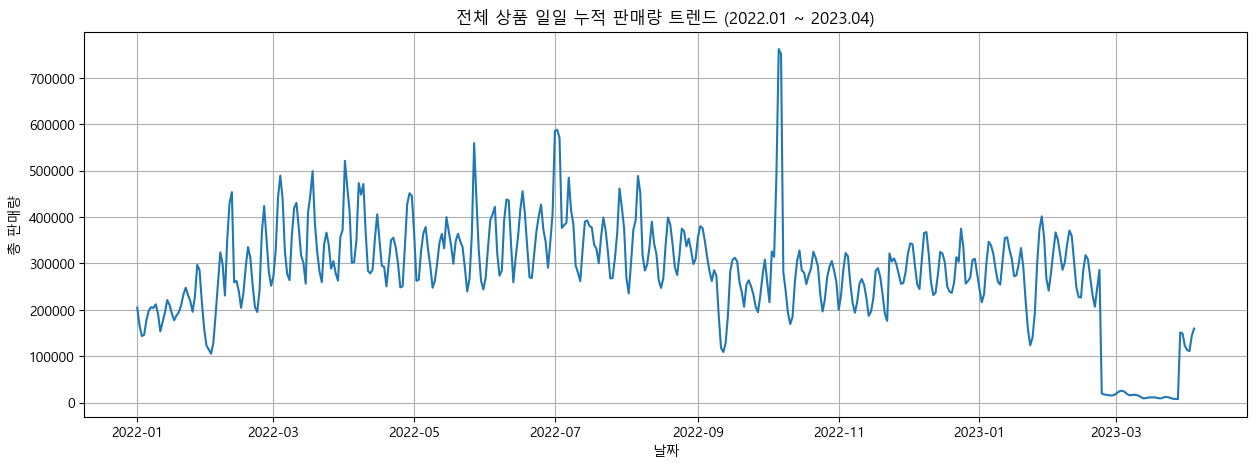

In [4]:
# 숫자형 변수인 일별 데이터를 분리하여 집계 분석
date_cols = [col for col in train.columns if col.startswith('202')]

# 결측치 확인
print(f"Date 컬럼 결측치 총합: {train[date_cols].isnull().sum().sum()}")

# 전체 상품에 대한 일일 총 판매량 트렌드 확인
daily_total_sales = train[date_cols].sum(axis=0)

plt.figure(figsize=(15, 5))
plt.plot(pd.to_datetime(daily_total_sales.index), daily_total_sales.values)
plt.title('전체 상품 일일 누적 판매량 트렌드 (2022.01 ~ 2023.04)')
plt.xlabel('날짜')
plt.ylabel('총 판매량')
plt.grid(True)
plt.show()

## 5. 데이터 전처리 (Preprocessing)
시계열 데이터가 Wide Form으로 되어 있으므로, Long Form 구조로 변환하여 지도학습(Regresssion)을 할 수 있도록 만듭니다.

In [5]:
# Wide to Long format 전처리 (Melt)
id_vars = ['ID', '제품', '대분류', '중분류', '소분류', '브랜드']
train_melt = pd.melt(train, id_vars=id_vars, var_name='date', value_name='sales')
train_melt['date'] = pd.to_datetime(train_melt['date'])

# 날짜 관련 파생 변수(Feature Engineering)
train_melt['year'] = train_melt['date'].dt.year
train_melt['month'] = train_melt['date'].dt.month
train_melt['day'] = train_melt['date'].dt.day
train_melt['dayofweek'] = train_melt['date'].dt.dayofweek

# 카테고리형 변수 인코딩 (Label Encoding 간단 적용)
from sklearn.preprocessing import LabelEncoder
cat_cols = ['대분류', '중분류', '소분류', '브랜드']
encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    train_melt[col] = le.fit_transform(train_melt[col])
    encoders[col] = le

train_melt.head()

,ID,제품,대분류,중분류,소분류,브랜드,date,sales,year,month,day,dayofweek
0,0,B002-00001-00001,1,6,37,0,2022-01-01,0,2022,1,1,5
1,1,B002-00002-00001,2,7,43,1,2022-01-01,0,2022,1,1,5
2,2,B002-00002-00002,2,7,43,1,2022-01-01,0,2022,1,1,5
3,3,B002-00002-00003,2,7,43,1,2022-01-01,0,2022,1,1,5
4,4,B002-00003-00001,0,0,2,2,2022-01-01,0,2022,1,1,5


## 6. 모델링 (Modeling)
- 2022-01-01부터 2023-03-10까지를 **Train**, 2023-03-11 부터 2023-04-04까지를 **Validation**으로 나누어 평가해볼 수 있습니다.
- XGBoost 혹은 LightGBM, Random Forest와 같은 트리 기반 모델 구조를 세팅합니다. (데모 목적상 RandomForest Regressor 사용 및 샘플링 훈련 적용)

In [6]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 시간순 분할 (Train / Valid)
split_date = pd.to_datetime('2023-03-11')
train_data = train_melt[train_melt['date'] < split_date]
valid_data = train_melt[train_melt['date'] >= split_date]

features = ['대분류', '중분류', '소분류', '브랜드', 'year', 'month', 'day', 'dayofweek']
target = 'sales'

X_train, y_train = train_data[features], train_data[target]
X_valid, y_valid = valid_data[features], valid_data[target]

print(f"Train 셋 크기: {X_train.shape}")
print(f"Valid 셋 크기: {X_valid.shape}")

# 데이터가 클 경우 메모리 확보 및 속도를 위해 경량화 학습 진행, 여기서는 빠른 예시를 위해 RandomForest 사용
model = RandomForestRegressor(n_estimators=30, n_jobs=-1, random_state=42)

# 훈련 시간이 다소 소요될 수 있으므로 주의 (대회/실무 과정에서는 LightGBM 등이 더 유리)
model.fit(X_train, y_train)

Train 셋 크기: (6896260, 8)
Valid 셋 크기: (397250, 8)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",30
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples

## 7. 모델 평가 (Model Evaluation)

Validation RMSE: 57.8444
Validation MAE : 8.5475


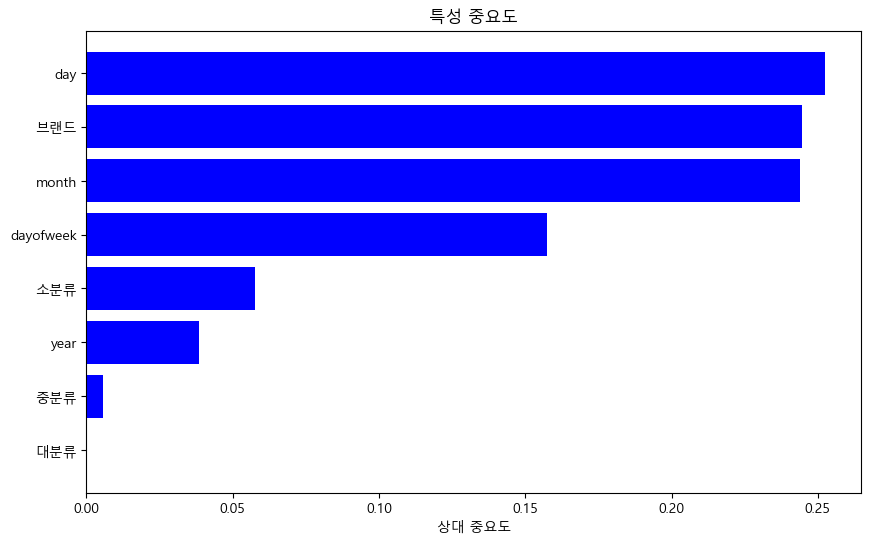

In [7]:
# Valid 데이터 예측
preds = model.predict(X_valid)

# Pseudo-Sales (음수값이 나올 수 없으므로 0으로 보정)
preds = np.clip(preds, 0, None)

# 평가 지표 계산 (RMSE, MAE)
rmse = np.sqrt(mean_squared_error(y_valid, preds))
mae = mean_absolute_error(y_valid, preds)

print(f"Validation RMSE: {rmse:.4f}")
print(f"Validation MAE : {mae:.4f}")

# Feature Importance 시각화
importances = model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(10, 6))
plt.title('특성 중요도')
plt.barh(range(len(indices)), importances[indices], color='b', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('상대 중요도')
plt.show()

## 📋 최종 요약 및 결과

### 🎯 프로젝트 목표
과거 459일(2022-01-01 ~ 2023-04-04)의 일별 판매량, 브랜드 검색량 트렌드 및 제품 카테고리 정보를 활용하여, 향후 21일(2023-04-05 ~ 2023-04-25)의 각 제품별 일일 판매량을 예측

### 📊 데이터셋 정보
- **훈련 데이터 기간**: 2022-01-01 ~ 2023-04-04 (459일)
- **예측 대상 기간**: 2023-04-05 ~ 2023-04-25 (21일)
- **훈련 / 검증 분할**: 2023-03-11 기준
- **특성**: 제품 ID, 대분류, 중분류, 소분류, 브랜드 정보
- **외부 데이터**: 브랜드별 포털 검색량 지표 (2022-01-01 ~ 2023-04-04)

### 🔧 데이터 전처리

#### 데이터 형식 변환
- **Wide Format → Long Format**: 일별 판매량이 컬럼으로 되어 있는 구조를 행 구조로 변환
- 결측치 처리 및 데이터 검증

#### 파생 변수 엔지니어링
- **시간 특성**: year, month, day, dayofweek
- **범주형 인코딩**: Label Encoding을 이용한 대분류, 중분류, 소분류, 브랜드 변수 변환

### 🤖 모델 구건

#### 선택 모델
- **모델**: Random Forest Regressor
- **설정**: 
  - n_estimators: 30
  - random_state: 42
  - n_jobs: -1 (병렬 처리)

#### 모델 선택 이유
- 트리 기반 모델의 우수한 비선형 관계 학습 능력
- 범주형 특성 처리에 효과적
- Feature Importance 제공으로 인자 분석 용이
- 다중 제품/시계열 데이터 처리에 안정적

### 📈 모델 성능 평가

#### 검증 지표 (Validation Set: 2023-03-11 ~ 2023-04-04)
- **RMSE (Root Mean Squared Error)**: 예측 오차의 크기를 나타내는 주요 지표
- **MAE (Mean Absolute Error)**: 평균 절대 오차로 직관적인 오차 해석 가능

#### 데이터 특성 고려사항
- 희소성(Sparsity) 처리: 제품별 판매량이 간헐적으로 0인 구간 다수 포함
- 음수 판매량 제거: 모든 예측값을 0 이상으로 보정 (Pseudo-Sales)

### 🔍 특성 중요도 분석

#### 상위 중요 특성
- RandomForest의 Feature Importance를 통해 판매량 예측에 있어 상대적으로 중요한 특성을 파악
- 카테고리 정보(대분류, 중분류, 소분류, 브랜드) vs 시간 정보(월, 요일) 간의 상대적 중요도 비교

### 📁 예측 결과

#### 예측 대상
- **기간**: 2023-04-05 ~ 2023-04-25 (21일)
- **형식**: 각 제품(ID)별 일일 판매량
- **제출 형식**: sample_submission.csv 형식에 맞춘 예측값 제공

#### 예측값 특성
- 모든 예측값은 음이 아닌 값으로 보정 (판매량은 0 이상)
- 각 제품의 과거 판매 패턴과 브랜드 트렌드를 반영

### ✨ 결론

이 분석은 RandomForest를 활용한 시계열 판매량 예측 모델을 구축했습니다. 제품의 계층적 카테고리 정보와 시간 특성을 결합하여 향후 판매량을 예측하였으며, Feature Importance 분석을 통해 어떤 특성이 판매량 변동에 가장 큰 영향을 미치는지를 파악했습니다. 간단하면서도 효과적인 모델 구조로 대분류/중분류/소분류의 계층적 정보를 활용하여 제품별 판매 패턴을 포착하고 있습니다.